#<font color = 'RED'> LINEAR REGRESSION

<font color = 'pink'> Step 1: Import Required Libraries

In [1]:
# Numerical Computing
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Data Preprocessing
from sklearn.preprocessing import StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Sklearn Linear Regression
from sklearn.linear_model import LinearRegression

# Evaluation Metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Style
plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

<font color = 'green'> STEP 2: LOAD THE DATASET

In this step, we will:

- Load the California Housing dataset.
- Convert it into a Pandas DataFrame.
- Display the first few rows.
- Check the dataset shape.
- Display the feature names.
- Check for missing values.
- View summary statistics.

In [2]:
# Step 2: Loading the California Housing Dataset
# Load the dataset
housing = fetch_california_housing()

# Feature matrix (Independent variables)
X = housing.data

# Target variable (House Price)
y = housing.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=housing.feature_names)

# Add target column
df["HousePrice"] = y


# Basic Information
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("Feature Names")
print("="*60)
print(df.columns.tolist())

print("\n")

print("="*60)
print("First Five Rows")
print("="*60)
display(df.head())

print("\n")

print("="*60)
print("Last Five Rows")
print("="*60)
display(df.tail())

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)
df.info()

print("\n")

print("="*60)
print("Missing Values")
print("="*60)
print(df.isnull().sum())

print("\n")

print("="*60)
print("Summary Statistics")
print("="*60)
display(df.describe())

Dataset Shape
(20640, 9)


Feature Names
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'HousePrice']


First Five Rows


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422




Last Five Rows


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894




Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Missing Values
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64


Summary Statistics


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<font color = 'blue'> STEP 3: Exploratory Data Analysis (EDA)

In this step we will visualize the dataset before training the model.

We will perform:

- Correlation Heatmap
- Feature Distributions (Histograms)
- Feature vs Target Scatter Plots
- Boxplots (to identify outliers)

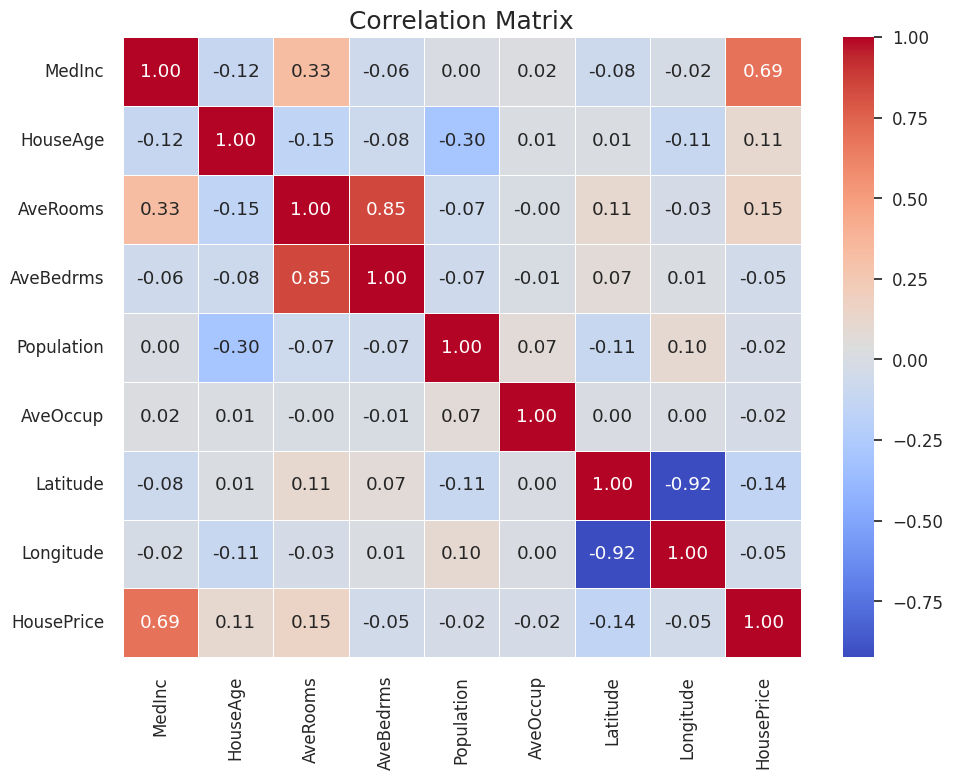

In [3]:
# Correlation Matrix
plt.figure(figsize=(10,8))

corr = df.corr()
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Matrix", fontsize=18)
plt.tight_layout()
plt.show()

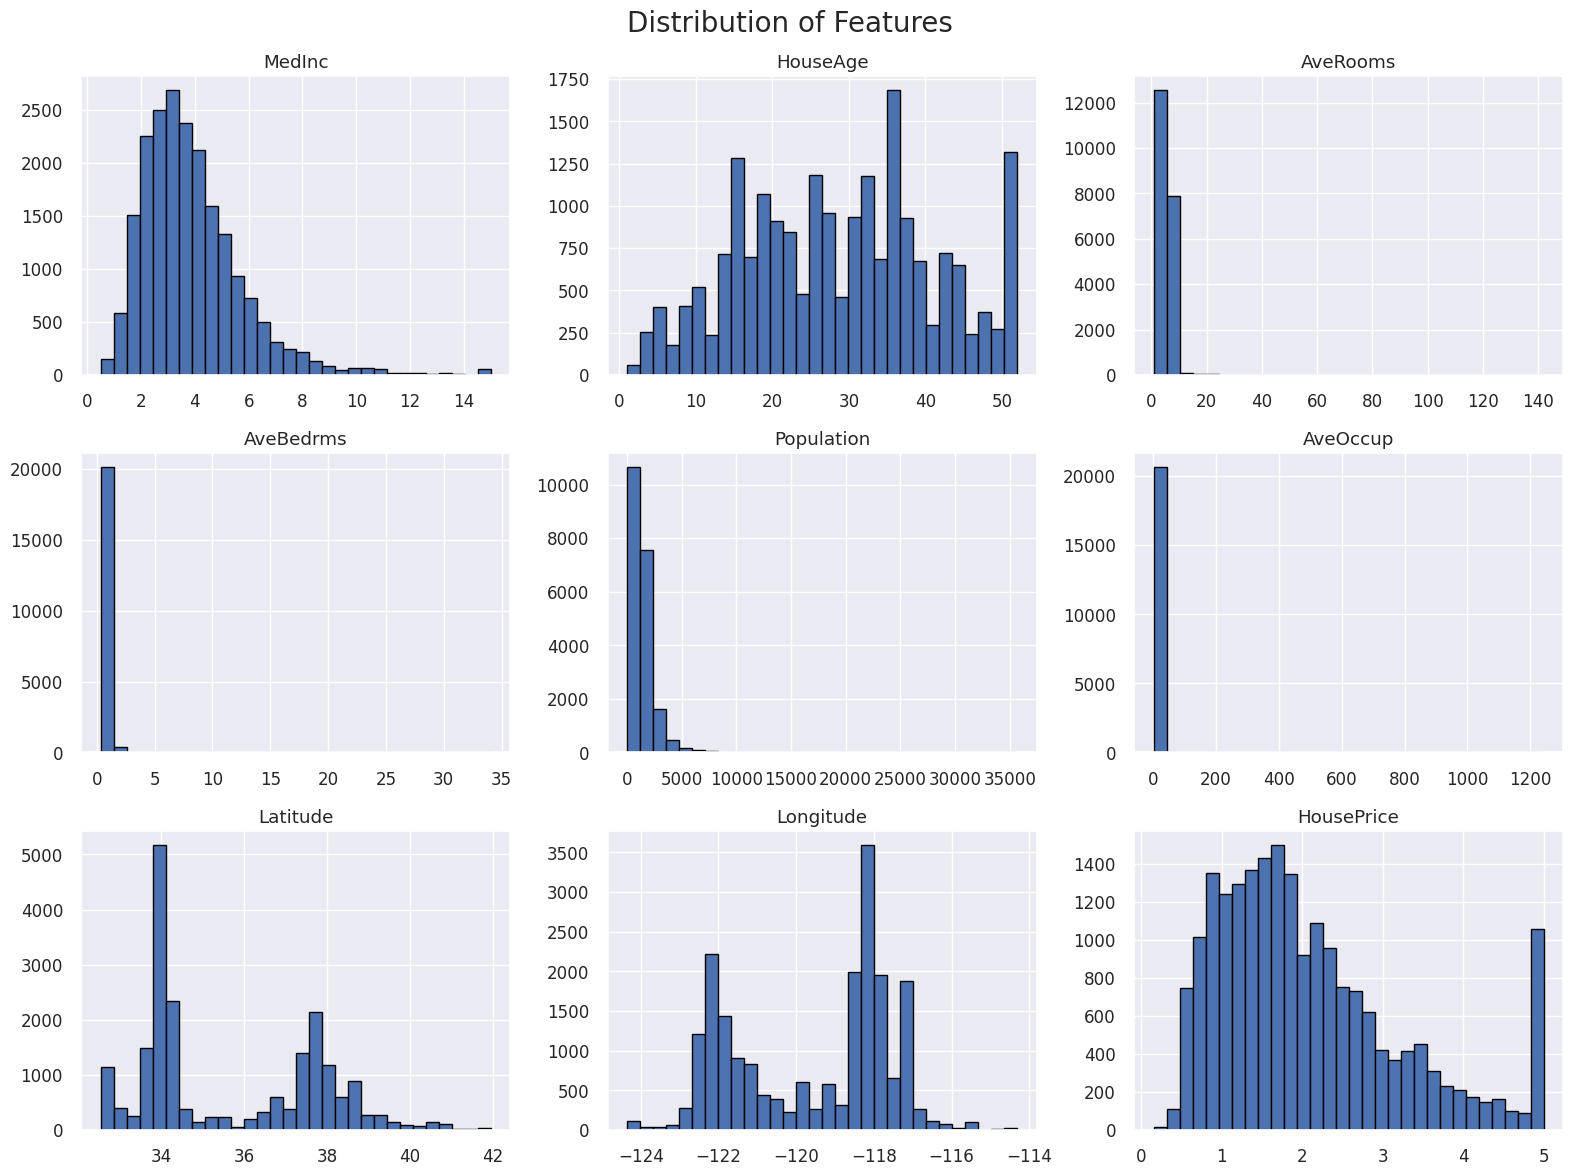

In [4]:
# Feature Distributions

df.hist(figsize=(16,12),bins=30,edgecolor="black")

plt.suptitle("Distribution of Features", fontsize=20)
plt.tight_layout()
plt.show()

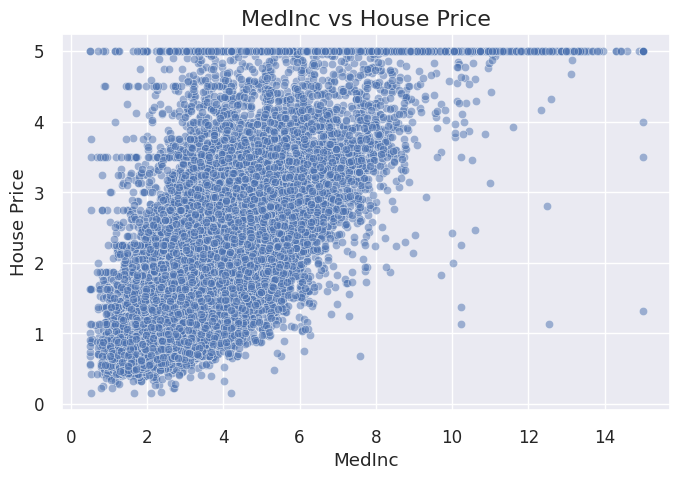

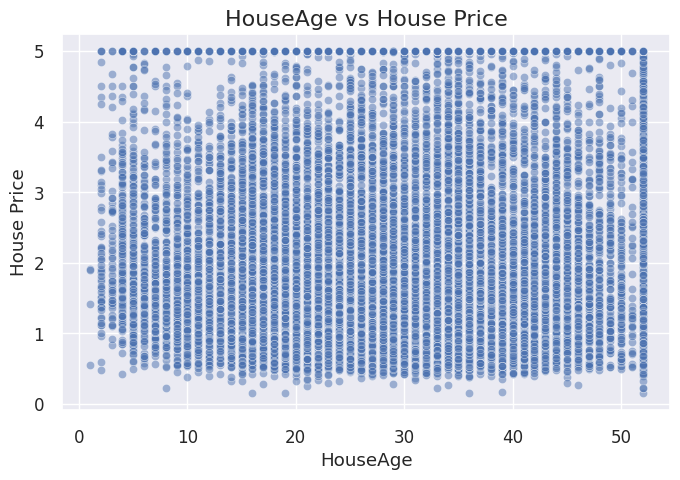

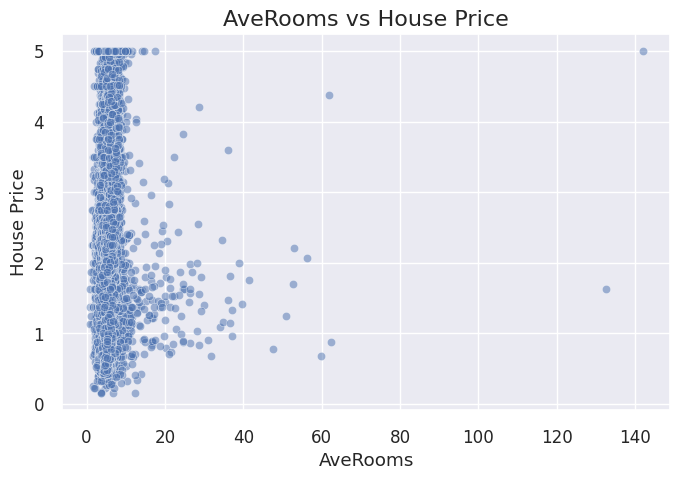

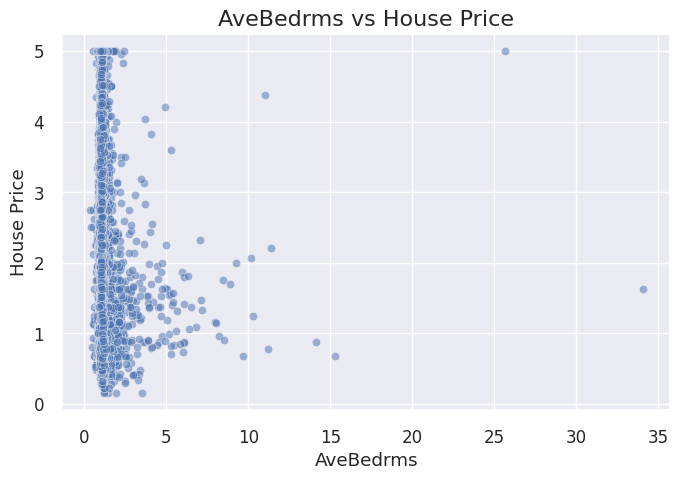

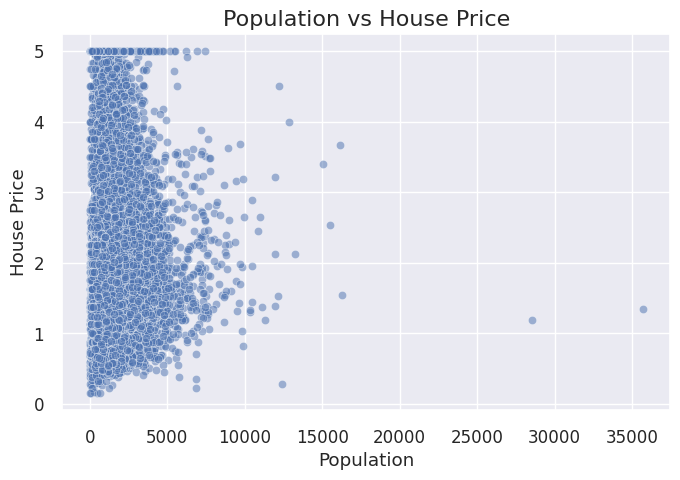

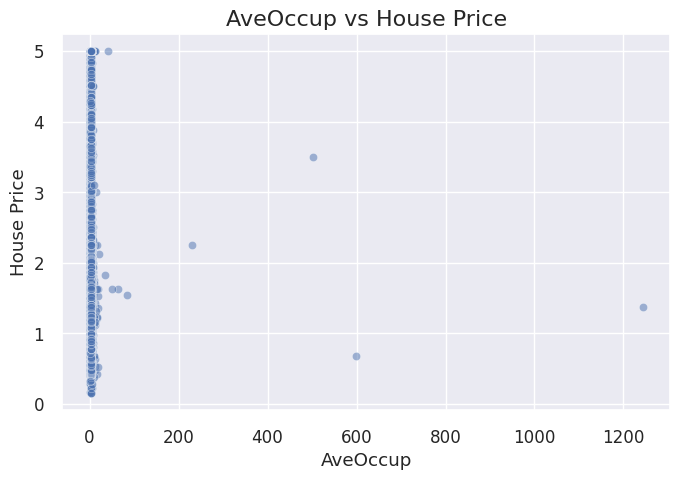

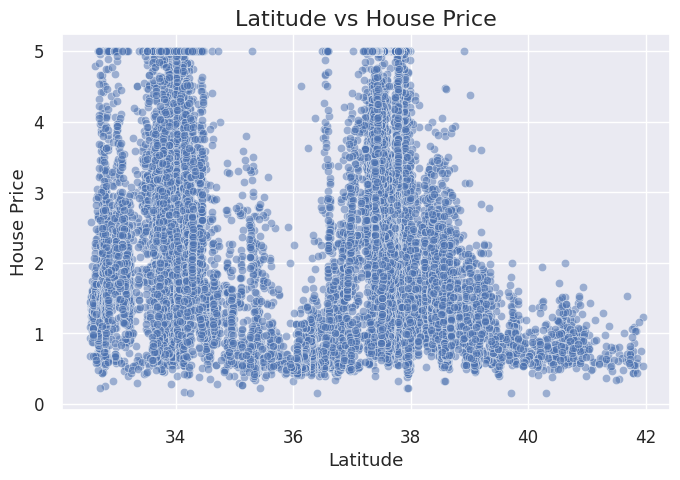

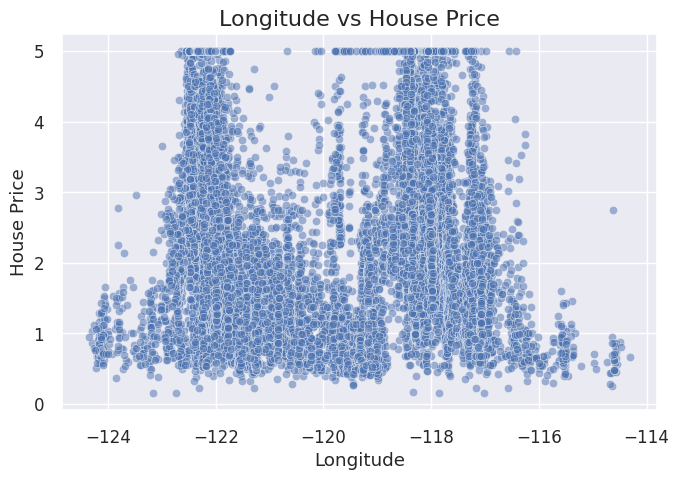

In [5]:
# Scatter Plot of Each Feature vs Target

features = housing.feature_names

for feature in features:

    plt.figure(figsize=(7,5))

    sns.scatterplot(data=df,x=feature,y="HousePrice",alpha=0.5)

    plt.title(f"{feature} vs House Price", fontsize=16)
    plt.xlabel(feature)
    plt.ylabel("House Price")

    plt.tight_layout()
    plt.show()

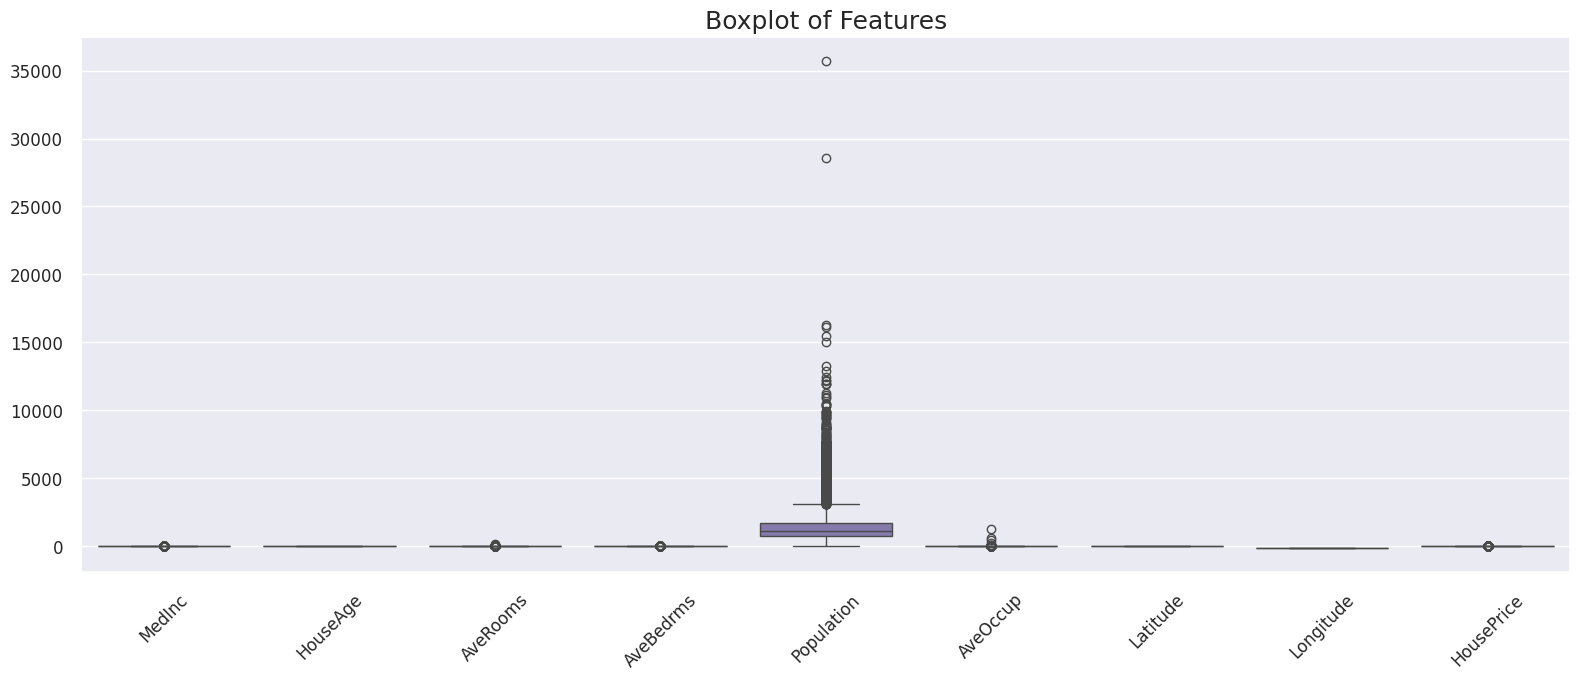

In [6]:
# Boxplots
plt.figure(figsize=(16,7))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of Features", fontsize=18)
plt.tight_layout()
plt.show()

# Boxplot answer these question
# Where is the middle of the data?
# How spread out is the data?
# Is the data symmetric or skewed?
# Are there any outliers?

- A pairplot is used to visualize the relationships between multiple numerical variables simultaneously.

- For a dataset with n numerical features, a pairplot creates an n×n grid:

       - Diagonal plots: Distribution of each individual variable (histogram or KDE).
       - Off-diagonal plots: Scatter plots between every pair of variables.

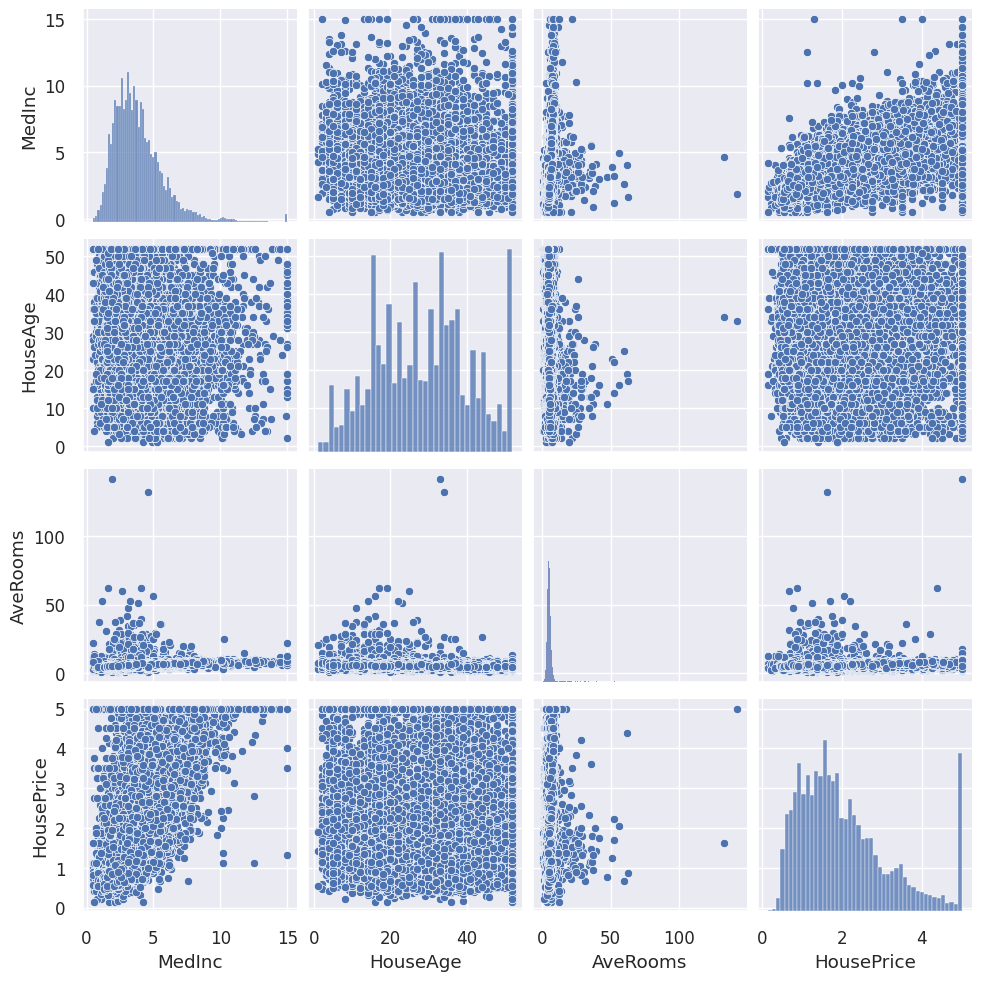

In [7]:
# Pair Plot
selected_columns = ["MedInc","HouseAge","AveRooms","HousePrice"]
sns.pairplot(df[selected_columns])
plt.show()

<font color = 'olive'> Step 4: Feature Scaling Objective

In this step, we will:

- Standardize all input features using StandardScaler
- Compare the features before and after scaling
- Verify that the scaled data has mean ≈ 0 and standard deviation ≈ 1


**Feature scaling is needed because many machine learning algorithms assume that all features are on comparable scales. If one feature has much larger numerical values than another, it can dominate the learning process, leading to poor or slower model performance.**

In [8]:
# Feature Scaling using StandardScaler

# Separate features and target
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# Create the scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to a DataFrame
X_scaled = pd.DataFrame(X_scaled,columns=X.columns)

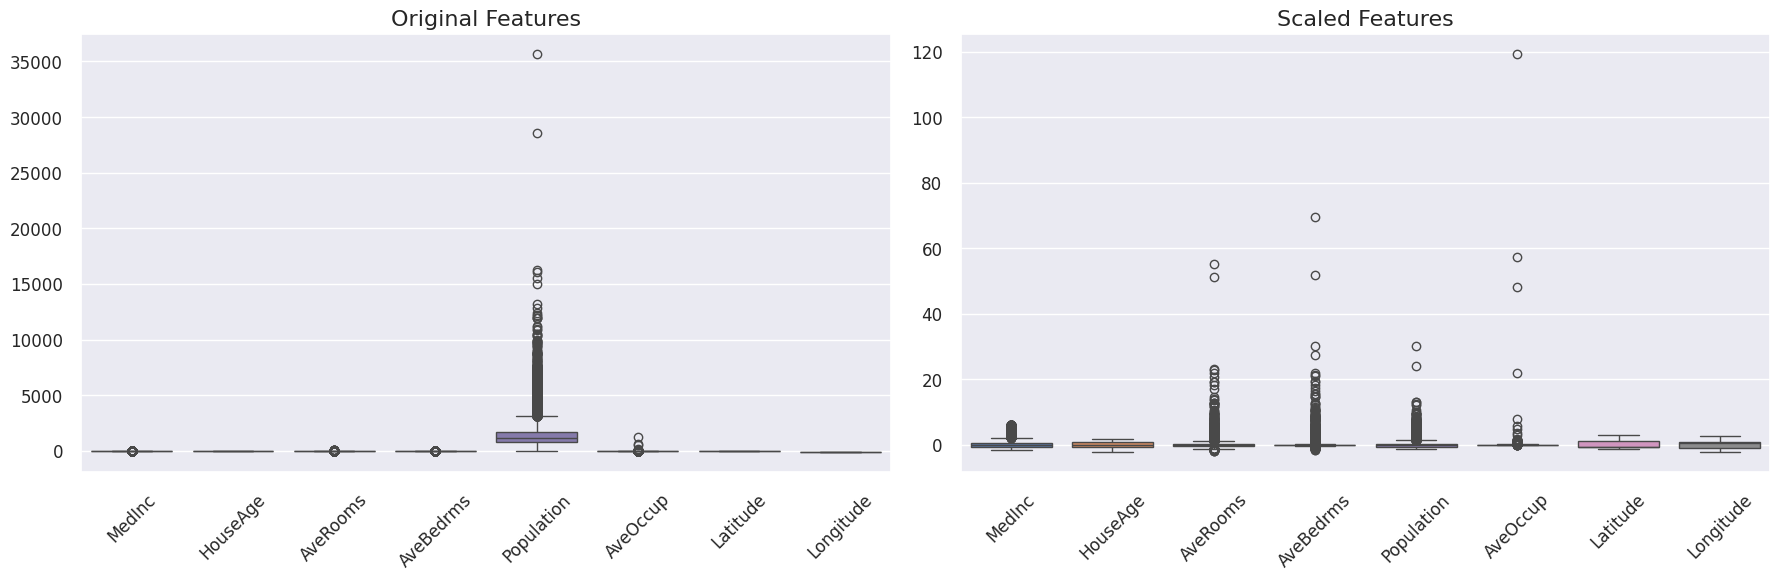

In [9]:
# Original vs Scaled Features
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Original Features
sns.boxplot(data=X, ax=axes[0])

axes[0].set_title("Original Features", fontsize=16)
axes[0].tick_params(axis='x', rotation=45)

# Scaled Features
sns.boxplot(data=X_scaled, ax=axes[1])

axes[1].set_title("Scaled Features", fontsize=16)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [10]:
# Mean and Standard Deviation After Scaling

scaled_statistics = pd.DataFrame({
    "Mean": X_scaled.mean(),
    "Standard Deviation": X_scaled.std()
})

display(scaled_statistics)

,Mean,Standard Deviation
MedInc,6.609700e-17,1.000024
HouseAge,5.508083e-18,1.000024
AveRooms,6.609700e-17,1.000024
AveBedrms,-1.060306e-16,1.000024
Population,-1.101617e-17,1.000024
AveOccup,3.442552e-18,1.000024
Latitude,-1.079584e-15,1.000024
Longitude,-8.526513e-15,1.000024


In [11]:
# Compare Original and Scaled Data

comparison = pd.concat([X.head(),X_scaled.head()],axis=1,keys=["Original Features", "Scaled Features"])

display(comparison)

Original Features                                                    \
             MedInc HouseAge  AveRooms AveBedrms Population  AveOccup   
0            8.3252     41.0  6.984127  1.023810      322.0  2.555556   
1            8.3014     21.0  6.238137  0.971880     2401.0  2.109842   
2            7.2574     52.0  8.288136  1.073446      496.0  2.802260   
3            5.6431     52.0  5.817352  1.073059      558.0  2.547945   
4            3.8462     52.0  6.281853  1.081081      565.0  2.181467   

                     Scaled Features                                           \
  Latitude Longitude          MedInc  HouseAge  AveRooms AveBedrms Population   
0    37.88   -122.23        2.344766  0.982143  0.628559 -0.153758  -0.974429   
1    37.86   -122.22        2.332238 -0.607019  0.327041 -0.263336   0.861439   
2    37.85   -122.24        1.782699  1.856182  1.155620 -0.049016  -0.820777   
3    37.85   -122.25        0.932968  1.856182  0.156966 -0.049833  -0.766028   
4    37.85   -122.25       -0.012881  1.856182  0.344711 -0.032906  -0.759847   

                                 
   AveOccup  Latitude Longitude  
0 -0.049597  1.052548 -1.327835  
1 -0.092512  1.043185 -1.322844  
2 -0.025843  1.038503 -1.332827  
3 -0.050329  1.038503 -1.337818  
4 -0.085616  1.038503 -1.337818

<font color = 'tale blue'> STEP 5: Train-Test Split

In [12]:
# Train-Validation-Test Split

# First split:
# 70% Training
# 30% Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled,y,test_size=0.30,random_state=42,shuffle=True)

# Second split:
# Split the remaining 30% equally into
# 15% Validation
# 15% Test

X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,random_state=42,shuffle=True)

In [13]:
# Dataset Shapes
print("="*50)
print("Training, Validation and Testing Shapes")
print("="*50)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print()

print(f"y_train : {y_train.shape}")
print(f"y_val   : {y_val.shape}")
print(f"y_test  : {y_test.shape}")

Training, Validation and Testing Shapes
X_train : (14448, 8)
X_val   : (3096, 8)
X_test  : (3096, 8)

y_train : (14448,)
y_val   : (3096,)
y_test  : (3096,)


In [14]:
# Verify Split Percentage

total_samples = len(df)

print("="*50)
print("Dataset Split Summary")
print("="*50)

print(f"Training Samples  : {len(X_train)} ({len(X_train)/total_samples*100:.2f}%)")
print(f"Validation Samples: {len(X_val)} ({len(X_val)/total_samples*100:.2f}%)")
print(f"Testing Samples   : {len(X_test)} ({len(X_test)/total_samples*100:.2f}%)")

Dataset Split Summary
Training Samples  : 14448 (70.00%)
Validation Samples: 3096 (15.00%)
Testing Samples   : 3096 (15.00%)


<font color = 'green'> Step 6: Implement Linear Regression from Scratch

# Mathematical Formulation

## 1. Hypothesis (Prediction Function)

The linear regression model predicts the target value as

$$
\hat{y} = X\theta
$$

where

- $X \in \mathbb{R}^{m \times (n+1)}$ : Feature matrix (including the intercept column)
- $\theta \in \mathbb{R}^{(n+1)}$ : Parameter vector
- $\hat{y}$ : Predicted target values

For a single training example,

$$
\hat{y}^{(i)} = \theta_0 + \theta_1x_1^{(i)} + \theta_2x_2^{(i)} + \cdots + \theta_nx_n^{(i)}
$$

---

## 2. Error

The prediction error is

$$
e = \hat{y} - y
$$

where

- $\hat{y}$ : Predicted values
- $y$ : Actual target values

---

## 3. Loss Function (Mean Squared Error)

The objective of Linear Regression is to minimize the Mean Squared Error (MSE):

$$
J(\theta)=\frac{1}{m}\sum_{i=1}^{m}\left(y^{(i)}-\hat{y}^{(i)}\right)^2
$$

where

- $m$ : Number of training samples
- $J(\theta)$ : Cost function

---

## 4. Gradient of the Loss Function

The gradient of the MSE with respect to the parameter vector is

$$
\nabla_{\theta}J(\theta)=\frac{2}{m}X^{T}(\hat{y}-y)
$$

---

## 5. Gradient Descent Update Rule

The parameters are updated iteratively using

$$
\theta \leftarrow \theta-\alpha\nabla_{\theta}J(\theta)
$$

Substituting the gradient,

$$
\boxed{
\theta
\leftarrow
\theta
-
\alpha
\left(
\frac{2}{m}
X^T(\hat{y}-y)
\right)
}
$$

where

- $\alpha$ : Learning rate

---

## 6. Training Loss

After every iteration, the training loss is computed as

$$
\text{Training MSE}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(y^{(i)}-\hat{y}^{(i)}\right)^2
$$

---

## 7. Validation Loss

The validation predictions are

$$
\hat{y}_{val}=X_{val}\theta
$$

The validation loss is

$$
\text{Validation MSE}
=
\frac{1}{m_{val}}
\sum_{i=1}^{m_{val}}
\left(y_{val}^{(i)}-\hat{y}_{val}^{(i)}\right)^2
$$

---

## 8. Complete Gradient Descent Algorithm

Initialize the parameter vector:

$$
\theta=\mathbf{0}
$$

For each iteration,

1. Compute predictions

$$
\hat{y}=X\theta
$$

2. Compute error

$$
e=\hat{y}-y
$$

3. Compute gradient

$$
\nabla_{\theta}J(\theta)
=
\frac{2}{m}X^Te
$$

4. Update parameters

$$
\theta
\leftarrow
\theta
-
\alpha
\nabla_{\theta}J(\theta)
$$

5. Compute the Training MSE.

6. Compute the Validation MSE.

Repeat until the maximum number of iterations is reached or the algorithm converges.

In [15]:
# Linear Regression using Gradient Descent

class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, iterations=1000):

        self.learning_rate = learning_rate
        self.iterations = iterations

        self.theta = None

        self.train_loss = []
        self.val_loss = []

    def add_intercept(self, X):
        """
        Add a column of ones to the feature matrix.
        """
        return np.c_[np.ones((X.shape[0], 1)), X]

    def compute_mse(self, y_true, y_pred):
        """
        Compute Mean Squared Error.
        """
        return np.mean((y_true - y_pred) ** 2)

    def predict(self, X):
        """
        Predict output values.
        """
        return X @ self.theta

    def fit(self, X_train, y_train, X_val, y_val):

        X_train = self.add_intercept(X_train)
        X_val = self.add_intercept(X_val)

        m, n = X_train.shape

        # Initialize parameters
        self.theta = np.zeros(n)

        # Gradient Descent
        for _ in range(self.iterations):

            # Forward Pass
            y_pred_train = self.predict(X_train)

            # Compute Error
            error = y_pred_train - y_train

            # Compute Gradient
            gradient = (2 / m) * X_train.T @ error

            # Update Parameters
            self.theta -= self.learning_rate * gradient

            # Training Loss
            train_mse = self.compute_mse(y_train,y_pred_train)

            self.train_loss.append(train_mse)

            # Validation Loss
            y_pred_val = self.predict(X_val)

            val_mse = self.compute_mse(y_val,y_pred_val)

            self.val_loss.append(val_mse)

# Create and fit the model
model = LinearRegressionGD(learning_rate=0.01, iterations=1000)
model.fit(X_train, y_train, X_val, y_val)

<font color = 'red'> STEP 7: Loss Plot

In [16]:
# Plot Loss Curve
def plot_loss(train_loss,val_loss,ylabel,title):

    plt.figure(figsize=(10,6))

    plt.plot(train_loss,linewidth=2,label="Training Loss")

    plt.plot(val_loss,'--',linewidth=2,label="Validation Loss")

    plt.xlabel("Iterations")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

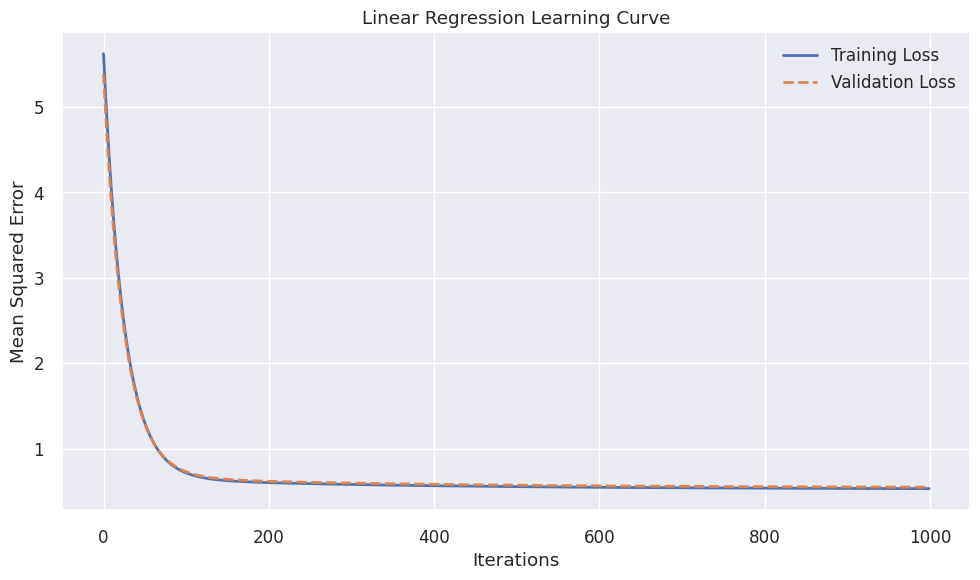

In [17]:
plot_loss(model.train_loss,model.val_loss,ylabel="Mean Squared Error",title="Linear Regression Learning Curve")

In [18]:
# Predict on the Test Set

# Add the intercept term to the test features
X_test_bias = model.add_intercept(X_test)

# Predict house prices
y_pred = model.predict(X_test_bias)

In [19]:
# Regression Evaluation

def regression_metrics(y_true, y_pred):
    """
    Compute regression evaluation metrics.
    """

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [20]:
metrics = regression_metrics(y_test, y_pred)

In [21]:
# Display Metrics
def print_metrics(title, metrics):

    print("="*55)
    print(title)
    print("="*55)

    for key, value in metrics.items():
        print(f"{key:<12}: {value:.4f}")

In [22]:
print_metrics("Linear Regression Metrics", metrics)

Linear Regression Metrics
MSE         : 0.5159
RMSE        : 0.7183
MAE         : 0.5228
R2          : 0.6098


In [23]:
# Expected vs Predicted Values

results = pd.DataFrame({
    "Expected Price": y_test.values,
    "Predicted Price": y_pred
})

# Display the first 10 predictions
display(results.head(10))

,Expected Price,Predicted Price
0,1.000,1.469064
1,1.188,0.908777
2,3.761,2.002820
3,2.000,2.341615
4,0.952,1.932067
5,1.285,1.636928
6,2.613,2.630644
7,1.794,2.321844
8,4.070,3.437446
9,1.750,1.290989


In [24]:
def plot_actual_vs_predicted(y_true,y_pred,title):

    plt.figure(figsize=(8,8))

    plt.scatter(y_true,y_pred,alpha=0.6,edgecolor="black")

    plt.plot([y_true.min(), y_true.max()],[y_true.min(), y_true.max()],color="red",linestyle="--",linewidth=2,label="Ideal Prediction")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

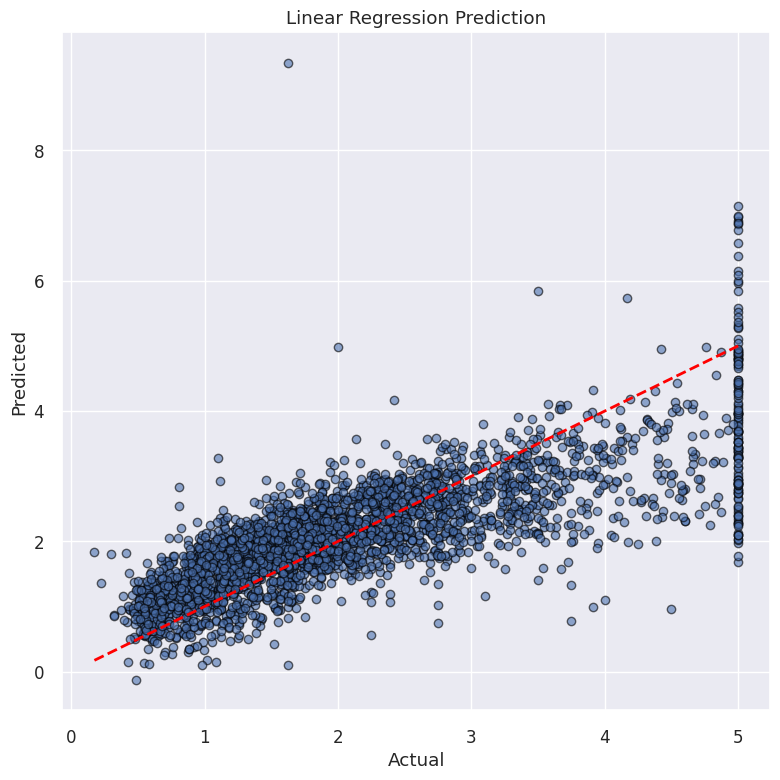

In [25]:
plot_actual_vs_predicted(y_test,y_pred,"Linear Regression Prediction")

**Interpretation of the Plot**

1. Positive Linear Relationship

- The scatter points generally follow an increasing trend.
- As the actual values increase, the predicted values also increase.
This indicates that the model has successfully learned the overall relationship between the input features and the target variable.

2. Predictions are Reasonably Close to the Ideal Trend

The red dashed line represents the general trend of the predictions.

If the model were perfect, all points would lie on the line

$\hat{y}$ = $y$
	​
(i.e., Predicted = Actual).

Since most points are clustered around the trend line, the model provides reasonably accurate predictions.

<font color = 'blue'> Step 7: Linear Regression using Scikit-learn

In [26]:
# Linear Regression using Scikit-learn

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

LinearRegression()

In [27]:
# Predict on the Test Set

y_pred_sklearn = lr_model.predict(X_test)

In [28]:
sklearn_metrics = regression_metrics(y_test, y_pred_sklearn)

print_metrics("Scikit-learn Linear Regression Metrics", sklearn_metrics)

Scikit-learn Linear Regression Metrics
MSE         : 0.5203
RMSE        : 0.7213
MAE         : 0.5210
R2          : 0.6066


In [29]:
# Expected vs Predicted Prices

results_sklearn = pd.DataFrame({
    "Expected Price": y_test.values,
    "Predicted Price": y_pred_sklearn
})

display(results_sklearn.head(10))

,Expected Price,Predicted Price
0,1.000,1.386085
1,1.188,0.806202
2,3.761,2.039045
3,2.000,2.318827
4,0.952,1.950201
5,1.285,1.604004
6,2.613,2.655491
7,1.794,2.359855
8,4.070,3.468561
9,1.750,1.369259


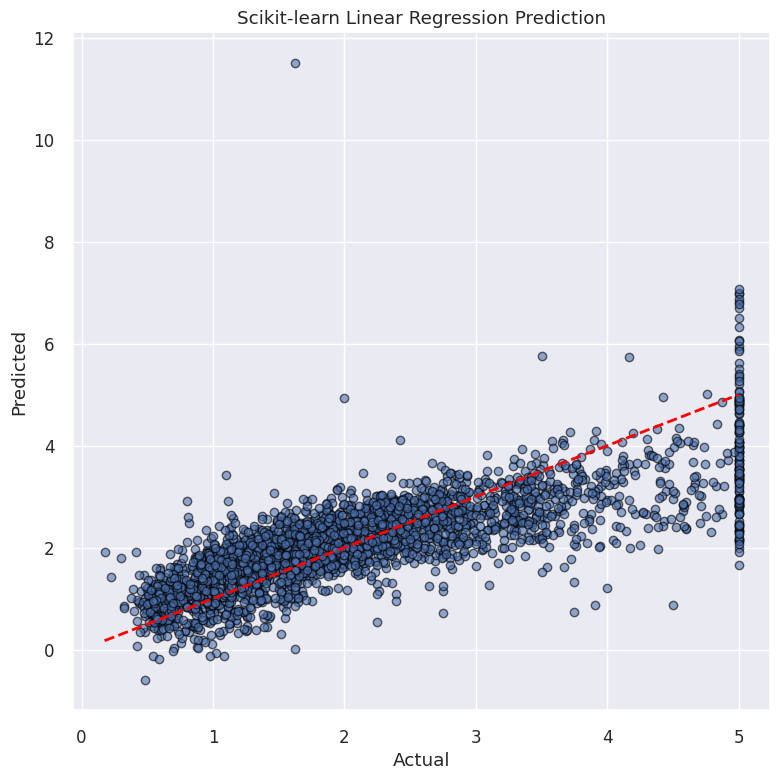

In [30]:
plot_actual_vs_predicted(y_test,y_pred_sklearn,"Scikit-learn Linear Regression Prediction")

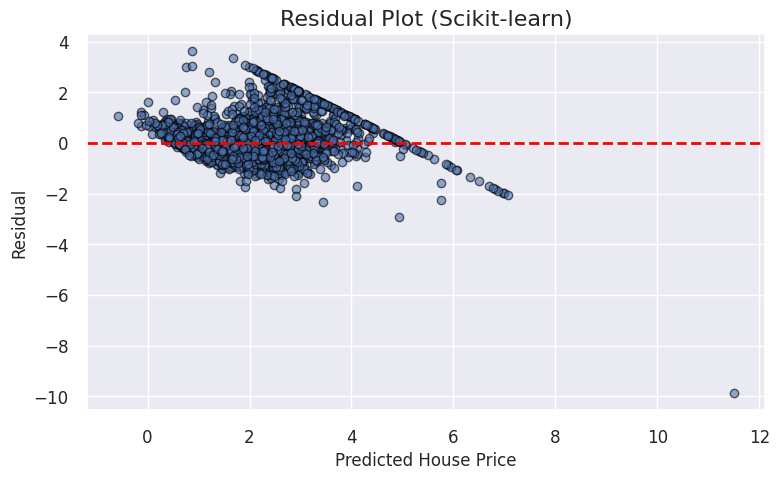

In [31]:
# Residual Plot

residuals_sk = y_test - y_pred_sklearn

plt.figure(figsize=(8,5))
plt.scatter(y_pred_sklearn,residuals_sk,alpha=0.6,edgecolor="black")
plt.axhline(y=0,color="red",linestyle="--",linewidth=2)
plt.xlabel("Predicted House Price", fontsize=12)
plt.ylabel("Residual", fontsize=12)
plt.title("Residual Plot (Scikit-learn)", fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

A residual plot answers the following questions:

1. Is the linear model appropriate?

If the residuals are randomly scattered around zero, then the linear model is a good fit.

2. Is there a pattern?

If the residuals form a curve, the relationship is probably nonlinear.

<font color = 'tale blue'> Step 8 : MODEL COMPARISON

In [32]:
def compare_models(scratch_metrics, sklearn_metrics):

    comparison = pd.DataFrame({
        "Metric": scratch_metrics.keys(),
        "Scratch": scratch_metrics.values(),
        "Scikit-learn": sklearn_metrics.values()
    })

    return comparison.round(4)

In [33]:
comparison = compare_models(metrics, sklearn_metrics)
display(comparison)

,Metric,Scratch,Scikit-learn
0,MSE,0.5159,0.5203
1,RMSE,0.7183,0.7213
2,MAE,0.5228,0.5210
3,R2,0.6098,0.6066


# <font color='purple'> POLYNOMIAL REGRESSION

# Polynomial Feature Transformation

Linear Regression assumes a linear relationship between the input features and the target variable. However, many real-world datasets exhibit nonlinear relationships. To capture these nonlinear patterns while still using a linear model, the original features are transformed into **polynomial features**.

Given an input feature vector

$$
X=[x_1,x_2,\ldots,x_n],
$$

Polynomial Features of degree \(d\) generate all combinations of the input features up to degree \(d\).

For **degree = 2**, the transformed feature vector becomes

$$
\phi(X)=
\left[
x_1,\;
x_2,\;
\ldots,\;
x_n,\;
x_1^2,\;
x_2^2,\;
\ldots,\;
x_n^2,\;
x_1x_2,\;
x_1x_3,\;
\ldots,\;
x_{n-1}x_n
\right].
$$

Thus, the Linear Regression model is applied to the transformed feature space as

$$
\hat{y}=\theta_0+\theta_1\phi_1(X)+\theta_2\phi_2(X)+\cdots+\theta_p\phi_p(X),
$$

where

- $\phi(X)$ denotes the polynomial feature transformation,
- $p$ is the total number of generated polynomial features.

In this implementation,

- Polynomial features of **degree 2** are generated.
- `include_bias=False` is used because the intercept (bias) term is added separately by the Linear Regression model.
- The transformation learned from the training data is applied to the validation and test datasets to ensure consistency.

The dimensions of the transformed datasets are printed to verify the increase in the number of input features after polynomial expansion.

In [38]:
# Importing polynomial features
from sklearn.preprocessing import PolynomialFeatures

# Generate the polynomial features
# Degree of polynomial
degree = 2

# Create Polynomial Features
poly = PolynomialFeatures(degree=degree,include_bias=False)

# Transform the datasets
X_train_poly = poly.fit_transform(X_train)

X_val_poly = poly.transform(X_val)

X_test_poly = poly.transform(X_test)

print("="*60)
print("Polynomial Feature Shapes")
print("="*60)

print("Training :", X_train_poly.shape)
print("Validation :", X_val_poly.shape)
print("Testing :", X_test_poly.shape)

Polynomial Feature Shapes
Training : (14448, 44)
Validation : (3096, 44)
Testing : (3096, 44)


In [39]:
scaler = StandardScaler()

X_train_poly = scaler.fit_transform(X_train_poly)
X_val_poly = scaler.transform(X_val_poly)
X_test_poly = scaler.transform(X_test_poly)

In [40]:
poly_model = LinearRegressionGD(learning_rate=0.01,iterations=1000)

poly_model.fit(X_train_poly,y_train,X_val_poly,y_val)

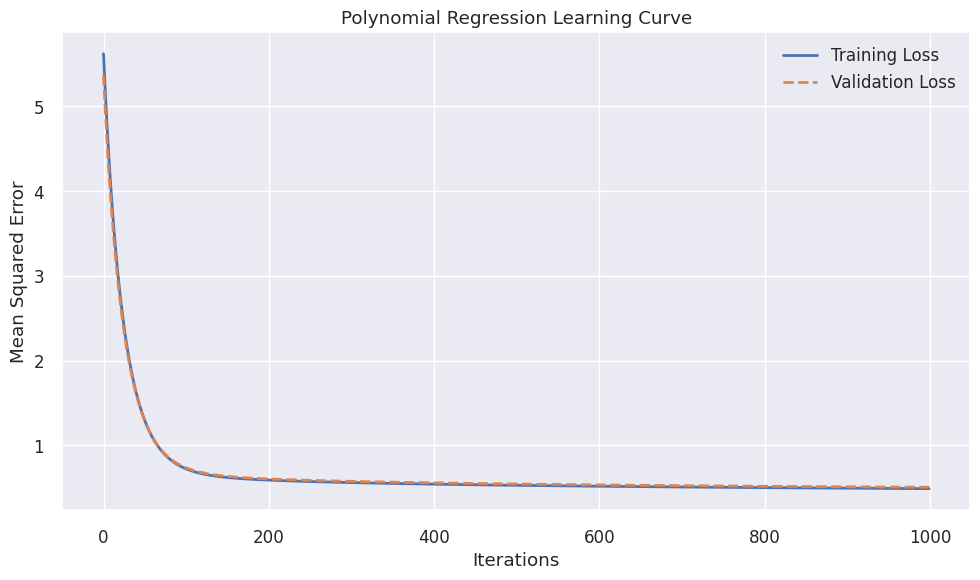

In [41]:
plot_loss(poly_model.train_loss,poly_model.val_loss,ylabel="Mean Squared Error",title="Polynomial Regression Learning Curve")

In [43]:
# Predict on test data
X_test_poly_intercept = poly_model.add_intercept(X_test_poly)

y_pred_poly = poly_model.predict(X_test_poly_intercept)

In [44]:
# Evaluate the model
# Compute evaluation metrics
poly_metrics = regression_metrics(y_test,y_pred_poly)

# Print metrics
print_metrics("Polynomial Regression Metrics",poly_metrics)

Polynomial Regression Metrics
MSE         : 0.4804
RMSE        : 0.6931
MAE         : 0.5042
R2          : 0.6367


In [45]:
# Prediction table
results_poly = pd.DataFrame({"Expected Price": y_test,"Predicted Price": y_pred_poly})

display(results_poly.head(10))

,Expected Price,Predicted Price
2457,1.000,1.403960
12273,1.188,0.835112
4081,3.761,2.011506
15537,2.000,2.357163
2915,0.952,2.108940
1282,1.285,1.581248
8698,2.613,2.678703
14235,1.794,2.400358
9006,4.070,3.496668
10221,1.750,1.432700


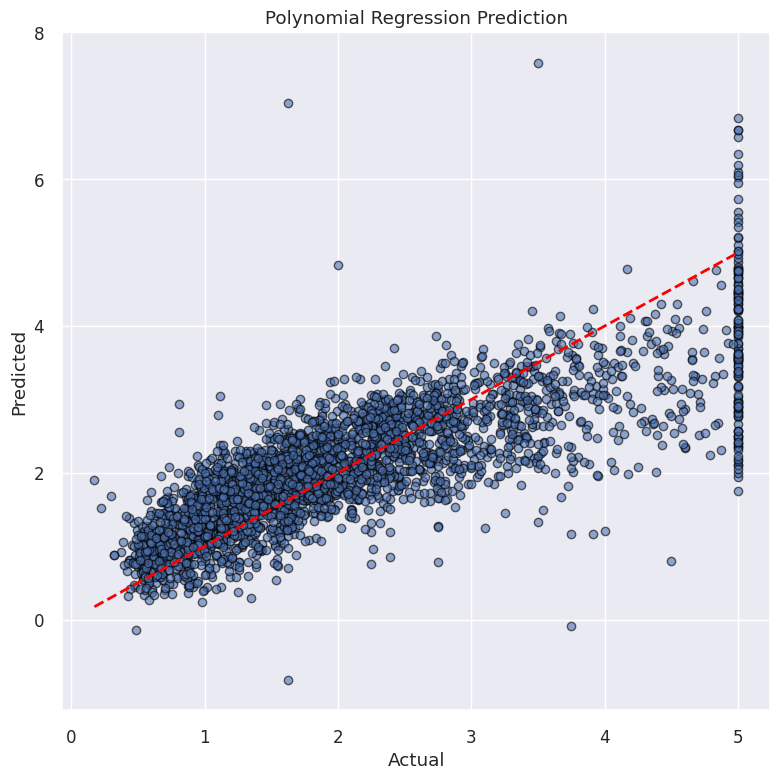

In [46]:
plot_actual_vs_predicted(y_test,y_pred_poly,"Polynomial Regression Prediction")

In [48]:
# Compare linear vs polynomial
comparison_lr_poly = pd.DataFrame({

    "Metric": metrics.keys(),

    "Linear Regression": metrics.values(),

    "Polynomial Regression": poly_metrics.values()

})

display(comparison_lr_poly.round(4))

,Metric,Linear Regression,Polynomial Regression
0,MSE,0.5159,0.4804
1,RMSE,0.7183,0.6931
2,MAE,0.5228,0.5042
3,R2,0.6098,0.6367


# <font color = 'green'> LOCALLY WEIGHTED REGRESSION (LWLR)

In [51]:
from sklearn.neighbors import NearestNeighbors

# Mathematical Overview of Locally Weighted Regression (LWR)

Unlike ordinary Linear Regression, **Locally Weighted Regression (LWR)** does not learn a single global model. Instead, for every query point, it fits a **local linear model** using nearby training samples, assigning larger weights to closer points.

---

## 1. Training Data

Given a training dataset

$$
\mathcal{D}
=
\left\{
(x^{(1)},y^{(1)}),
(x^{(2)},y^{(2)}),
\ldots,
(x^{(m)},y^{(m)})
\right\},
$$

where

- $m$ = number of training samples,
- $x^{(i)}\in\mathbb{R}^{n}$,
- $y^{(i)}$ = target value.

An intercept term is added to every feature vector,

$$
X=
\begin{bmatrix}
1 & x_1^{(1)} & x_2^{(1)} & \cdots & x_n^{(1)}\\
1 & x_1^{(2)} & x_2^{(2)} & \cdots & x_n^{(2)}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_1^{(m)} & x_2^{(m)} & \cdots & x_n^{(m)}
\end{bmatrix}.
$$

---

## 2. Finding the Nearest Neighbours

For a query point

$$
x_q,
$$

the Euclidean distance from every training sample is computed,

$$
d_i
=
\|x_q-x^{(i)}\|.
$$

The algorithm selects the **k nearest neighbours**

$$
\mathcal{N}(x_q).
$$

Only these neighbours are used to build the local regression model.

---

## 3. Gaussian Weight Function

Each neighbour is assigned a weight according to its distance from the query point.

The Gaussian kernel is

$$
w_i
=
\exp
\left(
-\frac{d_i^2}{2\tau^2}
\right),
$$

where

- $d_i$ = distance between the query point and the $i$-th neighbour,
- $\tau$ = bandwidth parameter.

Properties:

- Small distance $\Rightarrow$ large weight.
- Large distance $\Rightarrow$ small weight.

Thus, nearby observations influence the prediction more than distant observations.

---

## 4. Weight Matrix

The weights are arranged into a diagonal matrix,

$$
W=
\begin{bmatrix}
w_1&0&\cdots&0\\
0&w_2&\cdots&0\\
\vdots&\vdots&\ddots&\vdots\\
0&0&\cdots&w_k
\end{bmatrix}.
$$

---

## 5. Weighted Least Squares

Instead of minimizing the ordinary least squares objective,

$$
\sum_{i=1}^{k}
(y_i-\hat y_i)^2,
$$

LWR minimizes the **weighted least squares** objective,

$$
J(\theta)
=
\sum_{i=1}^{k}
w_i
\left(
y_i-x_i^T\theta
\right)^2.
$$

Nearby samples contribute more to the loss because they receive larger weights.

---

## 6. Closed-Form Solution

The optimal parameter vector is obtained by solving

$$
\boxed{
\theta
=
(X^TWX)^{-1}
X^TWy
}
$$

where

- $X$ = local design matrix,
- $W$ = diagonal weight matrix,
- $y$ = local target vector.

In the implementation, the Moore-Penrose pseudo-inverse is used,

$$
\boxed{
\theta
=
(X^TWX)^{+}
X^TWy
}
$$

which provides a stable solution even when $X^TWX$ is singular.

---

## 7. Prediction

Once the local parameters are computed, the prediction for the query point is

$$
\boxed{
\hat y
=
x_q^T\theta
}
$$

where

$$
x_q
=
[1,x_1,x_2,\ldots,x_n].
$$

---

# Algorithm

For each query point:

1. Find the **k nearest neighbours**.
2. Compute Euclidean distances.
3. Compute Gaussian weights

$$
w_i
=
\exp
\left(
-\frac{d_i^2}{2\tau^2}
\right).
$$

4. Construct the weight matrix

$$
W=\operatorname{diag}(w_1,w_2,\ldots,w_k).
$$

5. Compute the local regression coefficients

$$
\theta=(X^TWX)^{+}X^TWy.
$$

6. Predict

$$
\hat y=x_q^T\theta.
$$

---

# Advantages

- Captures nonlinear relationships.
- Makes flexible local predictions.
- No explicit training phase is required.
- Nearby samples have greater influence than distant samples.

---

# Limitations

- Computationally expensive because a new model is fitted for every query point.
- Prediction time is much slower than ordinary Linear Regression.
- Performance depends on the choice of bandwidth $\tau$ and the number of neighbours $k$.

In [52]:
class LocallyWeightedRegression:

    def __init__(self, tau=0.5, k=200):
        """
        tau : bandwidth parameter
        k   : number of nearest neighbours
        """

        self.tau = tau
        self.k = k

    def fit(self, X, y):

        self.X = np.asarray(X)
        self.y = np.asarray(y).reshape(-1)

        # Add intercept term
        self.X = np.c_[np.ones(self.X.shape[0]), self.X]

        # Build KD-Tree
        self.nn = NearestNeighbors(n_neighbors=self.k,algorithm="kd_tree")

        self.nn.fit(self.X[:,1:])

    def _predict_one(self, x):

        # Find nearest neighbours
        distances, indices = self.nn.kneighbors(x.reshape(1,-1))

        distances = distances.flatten()
        indices = indices.flatten()

        X_local = self.X[indices]
        y_local = self.y[indices]

        # Gaussian weights
        weights = np.exp(-(distances**2)/(2*self.tau**2))

        # Weighted Least Squares
        X_weighted = X_local * weights[:,None]

        theta = np.linalg.pinv(X_local.T @ X_weighted) @ (X_local.T @ (weights * y_local))

        # Prediction
        x = np.insert(x,0,1)

        return x @ theta

    def predict(self,X):

        X = np.asarray(X)

        predictions = np.zeros(len(X))

        for i in range(len(X)):
            predictions[i] = self._predict_one(X[i])

        return predictions

In [53]:
lwlr = LocallyWeightedRegression(tau=1.0,k=200)

lwlr.fit(X_train, y_train)

In [54]:
# Prediction
y_pred_lwlr = lwlr.predict(X_test)

In [55]:
# Evaluation
lwlr_metrics = regression_metrics(y_test,y_pred_lwlr)

print_metrics("Locally Weighted Regression Metrics",lwlr_metrics)

Locally Weighted Regression Metrics
MSE         : 0.3052
RMSE        : 0.5525
MAE         : 0.3883
R2          : 0.7692


In [56]:
# Prediction Table
results_lwlr = pd.DataFrame({

    "Expected Price": np.ravel(y_test),
    "Predicted Price": np.ravel(y_pred_lwlr)

})

display(results_lwlr.head(10))

,Expected Price,Predicted Price
0,1.000,0.899270
1,1.188,1.016050
2,3.761,3.185944
3,2.000,1.156741
4,0.952,1.920732
5,1.285,1.512021
6,2.613,2.287378
7,1.794,1.767454
8,4.070,4.311680
9,1.750,1.702390


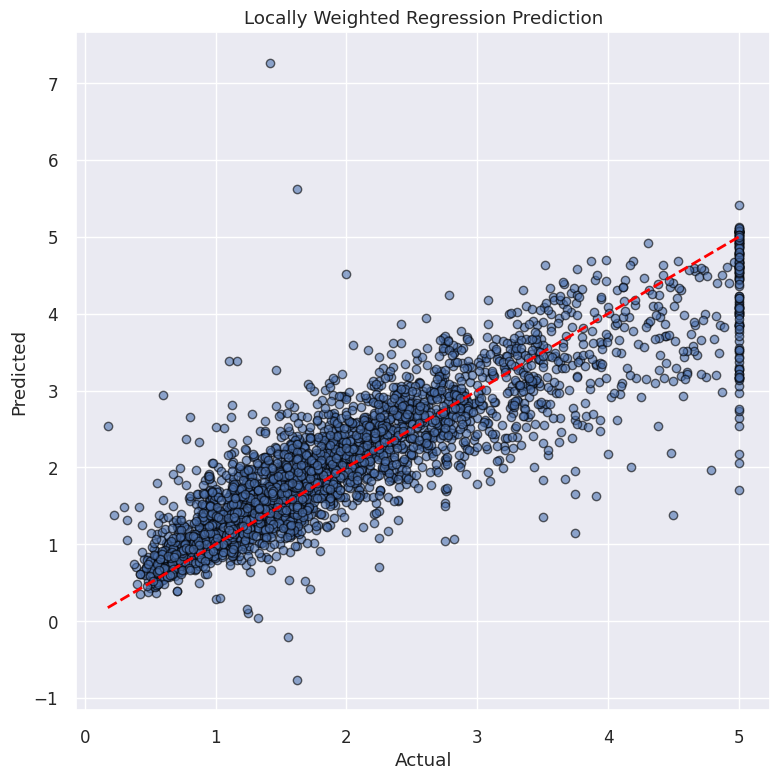

In [57]:
# Actual vs. predicted
plot_actual_vs_predicted(
    np.ravel(y_test),    # np.ravel() convert multidimensional array into one dimentional. In this case it converts (m,1) to (m,)
    np.ravel(y_pred_lwlr),
    "Locally Weighted Regression Prediction"
)

In [58]:
# Model comparison
comparison = pd.DataFrame({

    "Metric": metrics.keys(),

    "Linear Regression": metrics.values(),

    "Polynomial Regression": poly_metrics.values(),

    "Locally Weighted Regression": lwlr_metrics.values()

})

display(comparison.round(4))

,Metric,Linear Regression,Polynomial Regression,Locally Weighted Regression
0,MSE,0.5159,0.4804,0.3052
1,RMSE,0.7183,0.6931,0.5525
2,MAE,0.5228,0.5042,0.3883
3,R2,0.6098,0.6367,0.7692


# <font color = 'red'> LOGISTIC REGRESSION



### STEP 1:  Load the Iris dataset from scikit-learn: https://scikit-learn.org/1.5/auto_examples/datasets/plot_iris_dataset.html


In [59]:
# Importing the required libraries
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder

data= load_iris()
X = data.data
y=data.target.reshape(-1,1)   # To convert the shape from (150,) to (150,1)
# print(X.shape)
# print(y.shape)


In [60]:
# Here i convert X and y into a dataframe
df = pd.DataFrame(X,columns=data.feature_names)
df['Target']=y
df.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
50,7.0,3.2,4.7,1.4,1
85,6.0,3.4,4.5,1.6,1
117,7.7,3.8,6.7,2.2,2
14,5.8,4.0,1.2,0.2,0
111,6.4,2.7,5.3,1.9,2
136,6.3,3.4,5.6,2.4,2
96,5.7,2.9,4.2,1.3,1
114,5.8,2.8,5.1,2.4,2
54,6.5,2.8,4.6,1.5,1
53,5.5,2.3,4.0,1.3,1


### 2. Preprocess the dataset as required, i.e. feature scaling or standardization.

In [61]:
# This gives the brief overview of the data
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [62]:
# Checking if our data has null value of not
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
Target,0


In [63]:
# Here we scale the dataset using standard scaler
scaler = StandardScaler()

scaled_X = scaler.fit_transform(X)    # This is a numpy array so we need to convert it into dataframe

scaled_X_df = pd.DataFrame(scaled_X,columns=data.feature_names)

print(np.mean(scaled_X, axis=0))

np.std(scaled_X, axis=0)

[-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]


array([1., 1., 1., 1.])

### 3. Encode the class labels as one-hot vectors.

In [64]:
# Here we encode the class label using OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

en_label = ohe.fit_transform(y)

y_df = pd.DataFrame(en_label,columns=ohe.get_feature_names_out(['Target']))

new_df = pd.concat([scaled_X_df,y_df],axis=1)
new_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target_0,Target_1,Target_2
0,-0.900681,1.019004,-1.340227,-1.315444,1.0,0.0,0.0
1,-1.143017,-0.131979,-1.340227,-1.315444,1.0,0.0,0.0
2,-1.385353,0.328414,-1.397064,-1.315444,1.0,0.0,0.0
3,-1.506521,0.098217,-1.283389,-1.315444,1.0,0.0,0.0
4,-1.021849,1.249201,-1.340227,-1.315444,1.0,0.0,0.0


### 4. Show the class distribution of the dataset using a bar graph. Is the dataset balanced?

Target
0    50
1    50
2    50
Name: count, dtype: int64


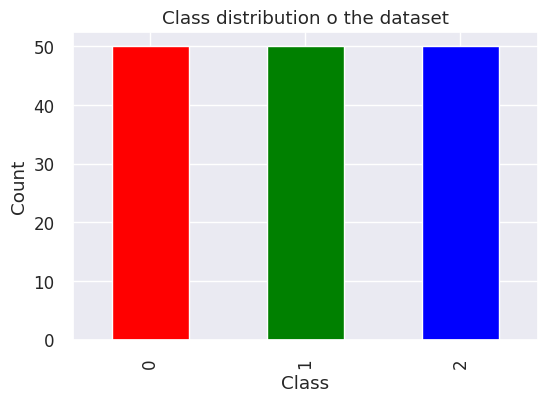

In [65]:
# Solution Code
plt.figure(figsize=(6,4))
class_label = df['Target'].value_counts()

print(class_label)

class_label.plot(kind='bar',color=['red','green','blue'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class distribution o the dataset')
plt.show()

### 5. Split the data into training, validation, and test sets (70%-15%-15%).

In [66]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(scaled_X, en_label, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### 6. Implement a softmax (multinomial) logistic regression model from scratch.

# Mathematical Overview of Softmax Regression

Softmax Regression (also called **Multinomial Logistic Regression**) is an extension of Logistic Regression used for **multi-class classification** problems. Instead of predicting probabilities for only two classes, it predicts the probability distribution over multiple classes.

---

## 1. Input Representation

Consider a training dataset

$$
\mathcal{D}
=
\left\{
(x^{(1)},y^{(1)}),
(x^{(2)},y^{(2)}),
\ldots,
(x^{(m)},y^{(m)})
\right\},
$$

where

- $m$ = number of training samples,
- $n$ = number of input features,
- $K$ = number of classes.

The input feature matrix is

$$
X\in\mathbb{R}^{m\times n}.
$$

The target labels are represented using **one-hot encoding**,

$$
y^{(i)}
=
[0,\ldots,1,\ldots,0].
$$

---

## 2. Linear Transformation (Logits)

For every input sample, a linear transformation is performed

$$
Z=XW+b,
$$

where

- $W\in\mathbb{R}^{n\times K}$ is the weight matrix,
- $b\in\mathbb{R}^{1\times K}$ is the bias vector,
- $Z$ is called the **logit matrix**.

Each row of $Z$ contains one score for every class.

---

## 3. Softmax Function

The logits are converted into probabilities using the Softmax function.

For the $j^{th}$ class,

$$
P(y=j|x)
=
\frac{e^{z_j}}
{\sum_{k=1}^{K}e^{z_k}}.
$$

To improve numerical stability, the maximum logit is subtracted before exponentiation,

$$
z=z-\max(z).
$$

The output probabilities satisfy

$$
0\le P(y=j|x)\le1,
$$

and

$$
\sum_{j=1}^{K}P(y=j|x)=1.
$$

---

## 4. Cross-Entropy Loss

The prediction error is measured using the Cross-Entropy Loss

$$
J(W)
=
-\frac{1}{m}
\sum_{i=1}^{m}
\sum_{j=1}^{K}
y_{ij}
\log(\hat y_{ij}),
$$

where

- $y_{ij}$ is the true one-hot label,
- $\hat y_{ij}$ is the predicted probability.

A smaller cross-entropy loss indicates better classification performance.

---

## 5. L2 Regularization

To reduce overfitting, an L2 penalty is added to the loss function,

$$
J(W)
=
-\frac{1}{m}
\sum_{i=1}^{m}
\sum_{j=1}^{K}
y_{ij}
\log(\hat y_{ij})
+
\frac{\lambda}{2m}
\|W\|_2^2,
$$

where

$$
\|W\|_2^2
=
\sum W_{ij}^2,
$$

and

- $\lambda$ is the regularization parameter.

---

## 6. Gradient Computation

The gradient of the loss with respect to the weight matrix is

$$
\frac{\partial J}{\partial W}
=
\frac{1}{m}
X^T(\hat Y-Y)
+
\frac{\lambda}{m}W,
$$

where

- $\hat Y$ = predicted probability matrix,
- $Y$ = one-hot encoded labels.

The gradient of the bias vector is

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat y^{(i)}-y^{(i)}).
$$

---

## 7. Gradient Descent Update

The parameters are updated iteratively using Gradient Descent.

### Weight Update

$$
W
\leftarrow
W
-
\alpha
\frac{\partial J}{\partial W},
$$

### Bias Update

$$
b
\leftarrow
b
-
\alpha
\frac{\partial J}{\partial b},
$$

where

- $\alpha$ is the learning rate.

---

## 8. Prediction

For a new input sample,

1. Compute the logits

$$
z=xW+b.
$$

2. Compute the Softmax probabilities

$$
\hat y=\text{Softmax}(z).
$$

3. Predict the class having the highest probability,

$$
\boxed{
\hat c
=
\arg\max_j
\hat y_j
}
$$

---

# Complete Training Algorithm

**Input:**

- Training data $(X,Y)$
- Learning rate $\alpha$
- Number of epochs $T$
- Regularization parameter $\lambda$

**Initialize**

$$
W=\mathbf{0},\qquad
b=\mathbf{0}
$$

For each epoch:

1. Compute logits

$$
Z=XW+b
$$

2. Compute probabilities

$$
\hat Y=\text{Softmax}(Z)
$$

3. Compute Cross-Entropy Loss

$$
J(W)
=
-\frac1m
\sum Y\log(\hat Y)
+
\frac{\lambda}{2m}\|W\|^2
$$

4. Compute gradients

$$
dW
=
\frac1m
X^T(\hat Y-Y)
+
\frac{\lambda}{m}W
$$

$$
db
=
\frac1m
\sum(\hat Y-Y)
$$

5. Update parameters

$$
W
\leftarrow
W-\alpha dW
$$

$$
b
\leftarrow
b-\alpha db
$$

Repeat until the specified number of epochs is reached.

---

# Summary

Softmax Regression extends Logistic Regression to multi-class classification by transforming the linear outputs into class probabilities using the Softmax function. The model is trained by minimizing the Cross-Entropy Loss with L2 regularization using Gradient Descent. During prediction, the class with the highest predicted probability is selected as the final output.

In [191]:
class SoftmaxRegression:

    def __init__(self, learning_rate=0.01, n_epochs=1000, l2=0.01):

        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.l2 = l2

        self.W = None
        self.b = None

        self.train_loss = []
        self.val_loss = []

    # Softmax Function
    def softmax(self, z):

        z = z - np.max(z, axis=1, keepdims=True)

        exp_z = np.exp(z)

        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    # Cross Entropy Loss
    def compute_loss(self, y_true, y_pred, m):

        loss = -np.mean(np.sum(y_true * np.log(y_pred + 1e-15),axis=1))

        # L2 Regularization
        loss += (self.l2 / (2 * m)) * np.sum(self.W ** 2)

        return loss

    # Training
    def fit(self, X_train, y_train, X_val, y_val):

        m, n = X_train.shape
        k = y_train.shape[1]

        self.W = np.zeros((n, k))
        self.b = np.zeros((1, k))

        for epoch in range(self.n_epochs):

            # Forward Pass
            logits = X_train @ self.W + self.b

            probabilities = self.softmax(logits)

            # Compute Loss
            train_loss = self.compute_loss(y_train,probabilities,m)

            self.train_loss.append(train_loss)

            # Compute Gradients
            dW = (X_train.T @ (probabilities - y_train)) / m

            db = np.sum(probabilities - y_train,axis=0,keepdims=True) / m

            # L2 Gradient
            dW += (self.l2 / m) * self.W

            # Update Parameters
            self.W -= self.learning_rate * dW

            self.b -= self.learning_rate * db

            # Validation Loss
            val_logits = X_val @ self.W + self.b

            val_prob = self.softmax(val_logits)

            val_loss = self.compute_loss(y_val,val_prob,X_val.shape[0])

            self.val_loss.append(val_loss)

    # -----------------------------
    # Predict Probability
    # -----------------------------
    def predict_proba(self, X):

        logits = X @ self.W + self.b

        return self.softmax(logits)

    # -----------------------------
    # Predict Class
    # -----------------------------
    def predict(self, X):

        probabilities = self.predict_proba(X)

        return np.argmax(probabilities, axis=1)

In [192]:
model = SoftmaxRegression(learning_rate=0.01,n_epochs=1000,l2=0.01)

model.fit(X_train,y_train,X_val,y_val)

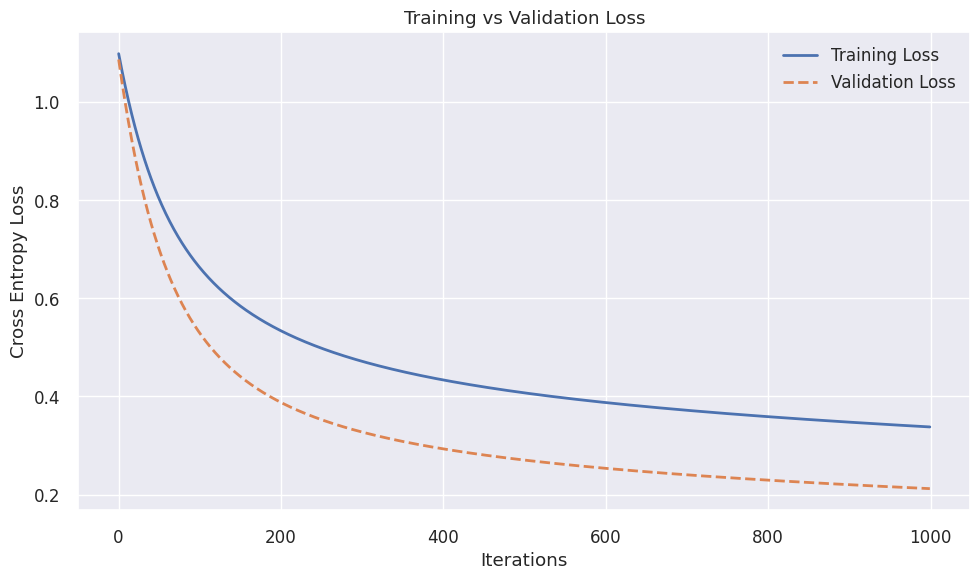

In [193]:
plot_loss(model.train_loss,model.val_loss,ylabel = 'Cross Entropy Loss',title = 'Training vs Validation Loss')

In [194]:
# Predict on the Test Set
# Predict the class labels
y_pred = model.predict(X_test)

In [195]:
# Convert One-Hot Labels to Class Labels
y_true = np.argmax(y_test, axis=1)

In [196]:
# Actual vs Predicted Classes

results = pd.DataFrame({
    "Actual Class": y_true,
    "Predicted Class": y_pred
})

display(results.head(15))

,Actual Class,Predicted Class
0,0,0
1,2,2
2,2,2
3,0,0
4,2,2
5,1,2
6,1,2
7,0,0
8,1,1
9,1,1


In [197]:
# Classification Evaluation

def classification_metrics(y_true, y_pred):
    """
    Compute classification evaluation metrics.
    """

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true,y_pred,average="weighted")
    recall = recall_score(y_true,y_pred,average="weighted")
    f1 = f1_score(y_true,y_pred,average="weighted")

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [198]:
scratch_imp_metrics = classification_metrics(y_true, y_pred)

print_metrics("Scratch Implementation", scratch_imp_metrics)

Scratch Implementation
Accuracy    : 0.7826
Precision   : 0.8732
Recall      : 0.7826
F1 Score    : 0.7750


In [199]:
def plot_confusion_matrix(y_true,y_pred,title,cmap="Blues"):

    cm = confusion_matrix(y_true,y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(cmap=cmap,values_format="d")
    plt.title(title)
    plt.grid(False)
    plt.show()

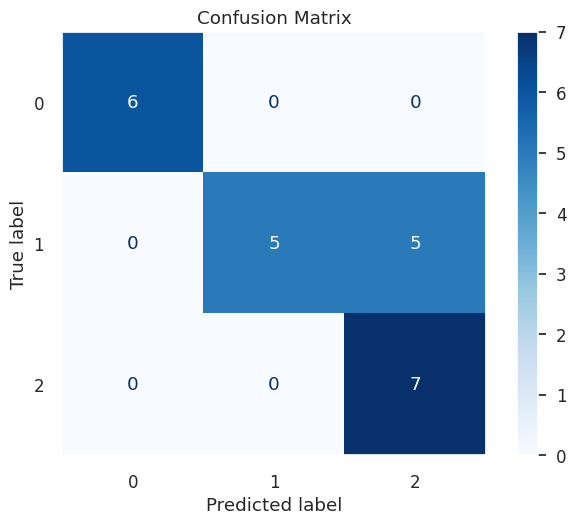

In [200]:
plot_confusion_matrix(y_true,y_pred,'Confusion Matrix')

In [201]:
# Classification Report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      0.50      0.67        10
           2       0.58      1.00      0.74         7

    accuracy                           0.78        23
   macro avg       0.86      0.83      0.80        23
weighted avg       0.87      0.78      0.77        23



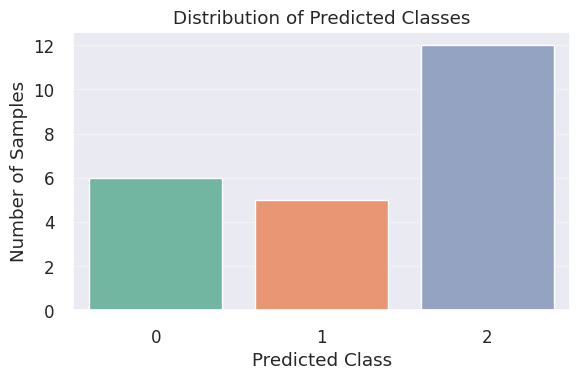

In [202]:
# Predicted Class Distribution

plt.figure(figsize=(6,4))

sns.countplot(x=y_pred,palette="Set2")

plt.xlabel("Predicted Class")
plt.ylabel("Number of Samples")

plt.title("Distribution of Predicted Classes")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [203]:
# Logistic Regression using Scikit-learn
from sklearn.linear_model import LogisticRegression
# Create the model
sklearn_model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    penalty="l2",
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Train the model
sklearn_model.fit(X_train, np.argmax(y_train, axis=1))

LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [204]:
# Predict on the Test Set
y_pred_sk = sklearn_model.predict(X_test)

In [205]:
sklearn_imp_metrics = classification_metrics(y_true, y_pred_sk)

print_metrics("Scikit-learn Logistic Regression", sklearn_imp_metrics)

Scikit-learn Logistic Regression
Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
F1 Score    : 1.0000


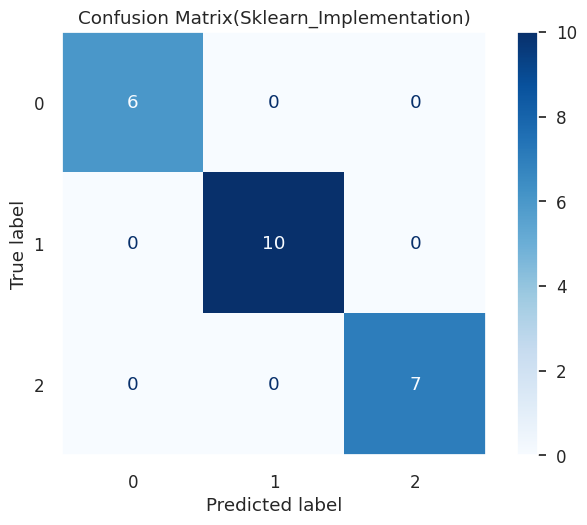

In [206]:
plot_confusion_matrix(y_true,y_pred_sk,'Confusion Matrix(Sklearn_Implementation)')

In [207]:
# Classification Report

print(classification_report(y_true, y_pred_sk))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00         7

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [208]:
comparison = compare_models(scratch_imp_metrics, sklearn_imp_metrics)
display(comparison)

,Metric,Scratch,Scikit-learn
0,Accuracy,0.7826,1.0
1,Precision,0.8732,1.0
2,Recall,0.7826,1.0
3,F1 Score,0.7750,1.0


# Assignment - 2 : [20 Marks]

## 1. Import required libraries and load the load_Wine Dataset from scikit-learn[MARKS 0]

## 2.Exploratory Data Analysis[2 Marks]

Perform the following analyses.

(a) Check
- Missing values
- Data types

(b) Visualize Class distribution

(c) Draw Correlation Heatmap

(d) Plot Histograms

(e) Generate Pair Plot

(f) Write your observations for each visualization.

## 3. Perform Feature Scaling and One-Hot Encoding[1 Marks]

- Use StandardScaler

- Compare Original features with Scaled features

- Display Mean , Standard deviation

- Convert the target labels into one-hot vectors.

- Display the encoded labels.

## 5. Split the data into training, validation, and test sets (70%-15%-15%). [Marks 1]

# 6. Implement Elastic-Net Softmax Regression from Scratch [6 Marks]

In this step, you will implement an **Elastic-Net Regularized Softmax Regression** model from scratch using **Gradient Descent**. **Do not use any machine learning library** (e.g., Scikit-learn, TensorFlow, or PyTorch) for model training.

Your implementation must include the following components.

---

## (a) Softmax Function

Implement the **Softmax activation function** to convert the raw logits into class probabilities.

The Softmax function should satisfy the following properties:

- The probability of each class lies between **0 and 1**.
- The sum of probabilities for each sample should be **equal to 1**.

---

## (b) Cross-Entropy Loss

Implement the **Multiclass Cross-Entropy Loss** to measure the difference between the predicted probabilities and the true class labels.

Your implementation should compute the average loss over all training samples.

---

## (c) L1 Regularization (Lasso)

Extend the loss function by adding an **L1 Regularization** term.

The L1 penalty is defined as

$$
L_{L1}=\lambda_1\sum_{i,j}|W_{ij}|
$$

where

- $W$ is the weight matrix.
- $\lambda_1$ is the L1 regularization parameter.

---

## (d) L2 Regularization (Ridge)

Further extend the loss function by adding an **L2 Regularization** term.

The L2 penalty is defined as

$$
L_{L2}=\frac{\lambda_2}{2}\sum_{i,j}W_{ij}^{2}
$$

where

- $W$ is the weight matrix.
- $\lambda_2$ is the L2 regularization parameter.

---

## (e) Gradient of L1 Regularization

Implement the gradient of the L1 regularization term.

The gradient is given by

$$
\frac{\partial |W|}{\partial W}=\operatorname{sign}(W)
$$

---

## (f) Gradient of L2 Regularization

Implement the gradient of the L2 regularization term.

The gradient is given by

$$
\frac{\partial}{\partial W}\left(\frac{\lambda_2}{2}\|W\|_2^2\right)=\lambda_2W
$$

---

## (g) Gradient Descent Optimization

Implement the complete **Gradient Descent** algorithm for training the model.

During each training epoch, your implementation must perform the following steps:

1. Compute the logits.
2. Apply the Softmax function.
3. Compute the Cross-Entropy Loss.
4. Add the L1 and L2 regularization terms.
5. Compute the gradients of the weights and bias.
6. Update the model parameters using Gradient Descent.
7. Store the **Training Loss**.
8. Compute and store the **Validation Loss**.

---

## Expected Outputs

After completing this step, your implementation should:

- Successfully train an Elastic-Net Softmax Regression model.
- Store the **training loss** after every epoch.
- Store the **validation loss** after every epoch.
- Learn the optimal weight matrix and bias vector.

> **Note**
>
> - You must implement the complete algorithm **from scratch**.
> - Do **not** use any built-in machine learning library for model training.
> - Only **NumPy** may be used for numerical computations.

# 7. Train the Model [1 Mark]

Train the **Elastic-Net Softmax Regression** model using the **Gradient Descent** algorithm.

---

## Training Configuration

Train the model for **1000 epochs**.

Select appropriate values for the following hyperparameters:

- **Learning Rate ($\alpha$)**
- **L1 Regularization Parameter ($\lambda_1$)**
- **L2 Regularization Parameter ($\lambda_2$)**

You may experiment with different values of these hyperparameters to achieve better model performance.


## 8. Plot Learning Curve[1 Mark]

- Plot Training Loss and Validation Loss

- Discuss Underfitting and Overfitting

## 9. Predict on test set[1 Mark]
 - display actual and predicted class

## 10. Evaluate the Model[1 Mark]

- compute Accuracy, precision, recall, f1_score

## 11. Plot the confusion matrix, Classification report and interpret the results.[1 Marks]

## 12. Perform the Sklearn Implementation and Compare the both model.[1 Marks]

# 13: Effect of Regularization[3 Marks]

In this section, analyze the effect of different regularization techniques on the performance of the **Softmax Regression** model.

Train the model using the following three configurations and compare the results.

---

## Case 1: No Regularization

Train the model without any regularization.

**Hyperparameters**

- L1 Regularization ($\lambda_1$) = **0**
- L2 Regularization ($\lambda_2$) = **0**

This serves as the baseline model.

---

## Case 2: L2 Regularization (Ridge)

Train the model using **only L2 Regularization**.

**Hyperparameters**

- L1 Regularization ($\lambda_1$) = **0**
- L2 Regularization ($\lambda_2$) = **0.01**

Observe how L2 regularization affects the model performance and the learning curves.

---

## Case 3: Elastic-Net Regularization

Train the model using **both L1 and L2 Regularization**.

**Hyperparameters**

- L1 Regularization ($\lambda_1$) = **0.01**
- L2 Regularization ($\lambda_2$) = **0.01**

Observe the combined effect of L1 and L2 regularization on the model.

---

## Compare the Following Performance Metrics

For each configuration, compute and compare:

- Accuracy
- Precision
- Recall
- F1-Score
- Training Loss
- Validation Loss

Present your results in the following table.

| Model | Accuracy | Precision | Recall | F1-Score | Training Loss | Validation Loss |
|--------|---------:|----------:|--------:|---------:|--------------:|----------------:|
| No Regularization | | | | | | |
| L2 Regularization | | | | | | |
| Elastic-Net Regularization | | | | | | |

---



## 14. Analysis[1 Marks]

Based on the experimental results, answer the following questions.

1. Which regularization technique achieved the highest classification accuracy?

2. How did L2 regularization affect the training and validation losses compared to the model without regularization?

3. What impact did adding L1 regularization have on the overall model performance?

4. Which model showed the best generalization performance on the validation and test datasets?

5. Which regularization technique would you recommend for this dataset? Justify your answer using the obtained results.